In [1]:
import pandas as pd       # Veri okuma, işleme, analiz
import numpy as np        # Sayısal işlemler ve diziler


In [3]:
df = pd.read_csv('/Users/hatice/Downloads/onlinefoods.csv')
print(df.head())


   Age  Gender Marital Status Occupation  Monthly Income  \
0   20  Female         Single    Student       No Income   
1   24  Female         Single    Student  Below Rs.10000   
2   22    Male         Single    Student  Below Rs.10000   
3   22  Female         Single    Student       No Income   
4   22    Male         Single    Student  Below Rs.10000   

  Educational Qualifications  Family size  latitude  longitude  Pin code  \
0              Post Graduate            4   12.9766    77.5993    560001   
1                   Graduate            3   12.9770    77.5773    560009   
2              Post Graduate            3   12.9551    77.6593    560017   
3                   Graduate            6   12.9473    77.5616    560019   
4              Post Graduate            4   12.9850    77.5533    560010   

  Output   Feedback Unnamed: 12  
0    Yes   Positive         Yes  
1    Yes   Positive         Yes  
2    Yes  Negative          Yes  
3    Yes   Positive         Yes  
4    Yes   P

In [4]:
## Sütun adlarını kontrol edelim
print(df.columns)

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')


In [5]:
# Veri tipi ve eksik veri kontrolü
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [6]:
# Örneğin: Age sütunu varsa yaş grubu oluştur
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Hangi yaş grubunda kaç kişi var (veya kaç sipariş var)
print(df['AgeGroup'].value_counts())


AgeGroup
19-25    268
26-35    119
0-18       1
36-45      0
46-60      0
60+        0
Name: count, dtype: int64


In [8]:
print(df.columns)

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12', 'AgeGroup'],
      dtype='object')


In [9]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12,AgeGroup
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes,19-25
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes,19-25
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes,19-25
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes,19-25
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes,19-25


/var/folders/6x/_krfj1sn7fq2yc6ghl0cq_q40000gn/T/ipykernel_28996/3956122227.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Output'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)


<Axes: xlabel='AgeGroup'>

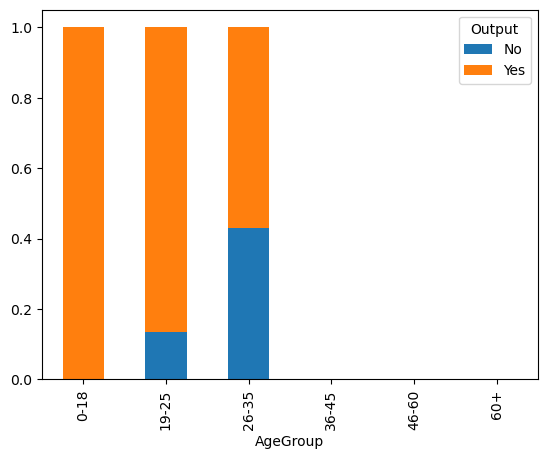

In [11]:
#  Hangi yaş grubu daha çok online sipariş veriyor?

df['AgeGroup'].value_counts()
df.groupby('AgeGroup')['Output'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)




In [12]:
age_order_counts = df[df['Output'] == 'Yes']['AgeGroup'].value_counts()
print(age_order_counts)


AgeGroup
19-25    232
26-35     68
0-18       1
36-45      0
46-60      0
60+        0
Name: count, dtype: int64


In [13]:
# En çok sipariş veren yaş grubundaki cinsiyet dağılımı

top_age = age_order_counts.idxmax()  # En çok sipariş veren yaş grubu
top_age_df = df[(df['AgeGroup'] == top_age) & (df['Output'] == 'Yes')]
print(top_age_df['Gender'].value_counts())


Gender
Male      129
Female    103
Name: count, dtype: int64


In [14]:
# En çok sipariş veren kullanıcıların yaş grubu ve cinsiyeti

df[df['Output'] == 'Yes'].groupby(['AgeGroup', 'Gender']).size().sort_values(ascending=False)


/var/folders/6x/_krfj1sn7fq2yc6ghl0cq_q40000gn/T/ipykernel_28996/2055360747.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['Output'] == 'Yes'].groupby(['AgeGroup', 'Gender']).size().sort_values(ascending=False)


AgeGroup  Gender
19-25     Male      129
          Female    103
26-35     Male       45
          Female     23
0-18      Male        1
          Female      0
36-45     Female      0
          Male        0
46-60     Female      0
          Male        0
60+       Female      0
          Male        0
dtype: int64

In [15]:
# En çok sipariş veren bekar kişilerin cinsiyetleri

single_yes = df[(df['Marital Status'] == 'Single') & (df['Output'] == 'Yes')]
print(single_yes['Gender'].value_counts())
print(f"Toplam bekar kullanıcı sayısı (sipariş veren): {single_yes.shape[0]}")


Gender
Male      131
Female     98
Name: count, dtype: int64
Toplam bekar kullanıcı sayısı (sipariş veren): 229


/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


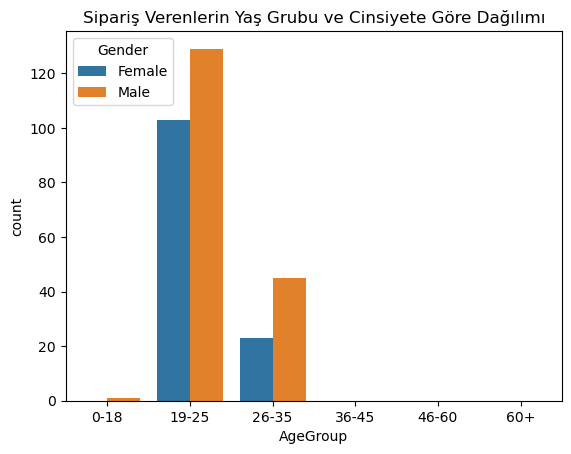

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df[df['Output'] == 'Yes'], x='AgeGroup', hue='Gender')
plt.title("Sipariş Verenlerin Yaş Grubu ve Cinsiyete Göre Dağılımı")
plt.show()


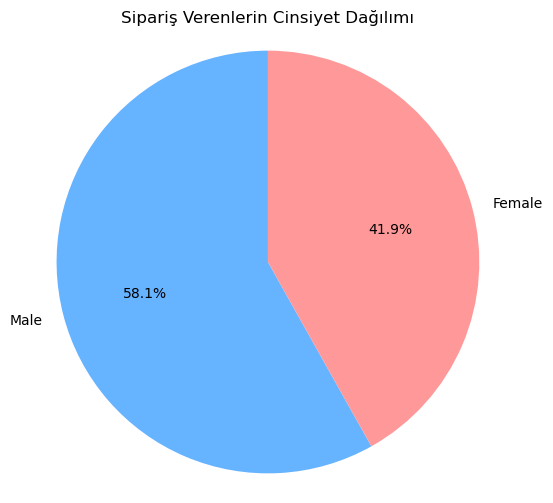

In [19]:
# Sipariş Verenlerin Cinsiyet Dağılımı (Pie Chart)

gender_counts = yes_df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title("Sipariş Verenlerin Cinsiyet Dağılımı")
plt.axis('equal')
plt.show()


/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


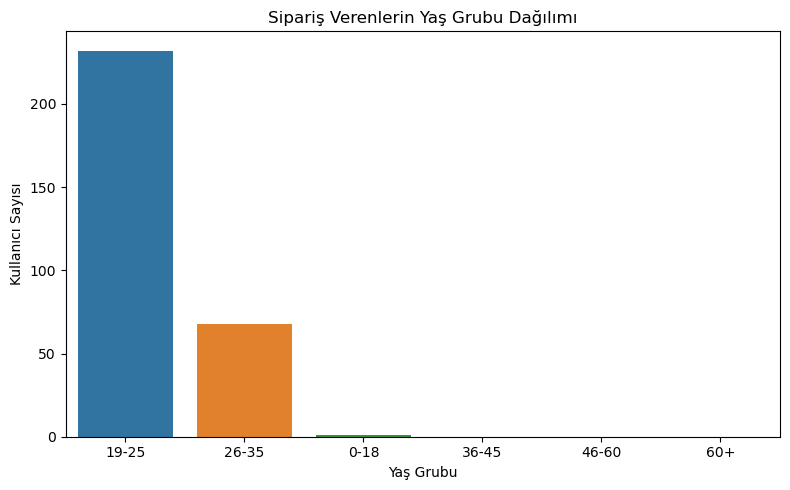

In [18]:

# Sadece sipariş verenler (Output = Yes)
yes_df = df[df['Output'] == 'Yes']

plt.figure(figsize=(8, 5))
sns.countplot(data=yes_df, x='AgeGroup', order=yes_df['AgeGroup'].value_counts().index)
plt.title("Sipariş Verenlerin Yaş Grubu Dağılımı")
plt.xlabel("Yaş Grubu")
plt.ylabel("Kullanıcı Sayısı")
plt.tight_layout()
plt.show()

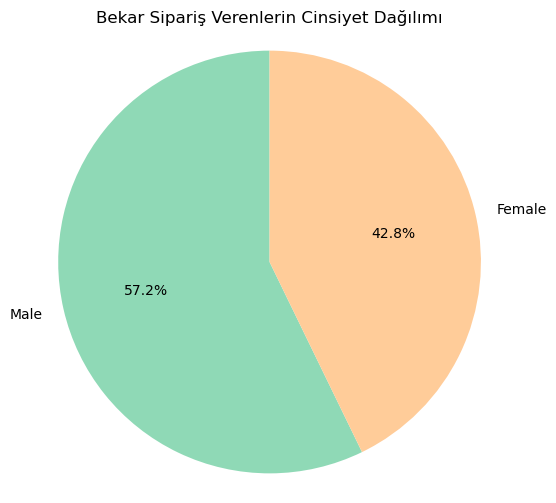

In [20]:
#Bekar Sipariş Verenlerin Cinsiyet Dağılımı (Pie Chart)


single_yes = df[(df['Marital Status'] == 'Single') & (df['Output'] == 'Yes')]
single_gender_counts = single_yes['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(single_gender_counts, labels=single_gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#8fd9b6', '#ffcc99'])
plt.title("Bekar Sipariş Verenlerin Cinsiyet Dağılımı")
plt.axis('equal')
plt.show()


/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


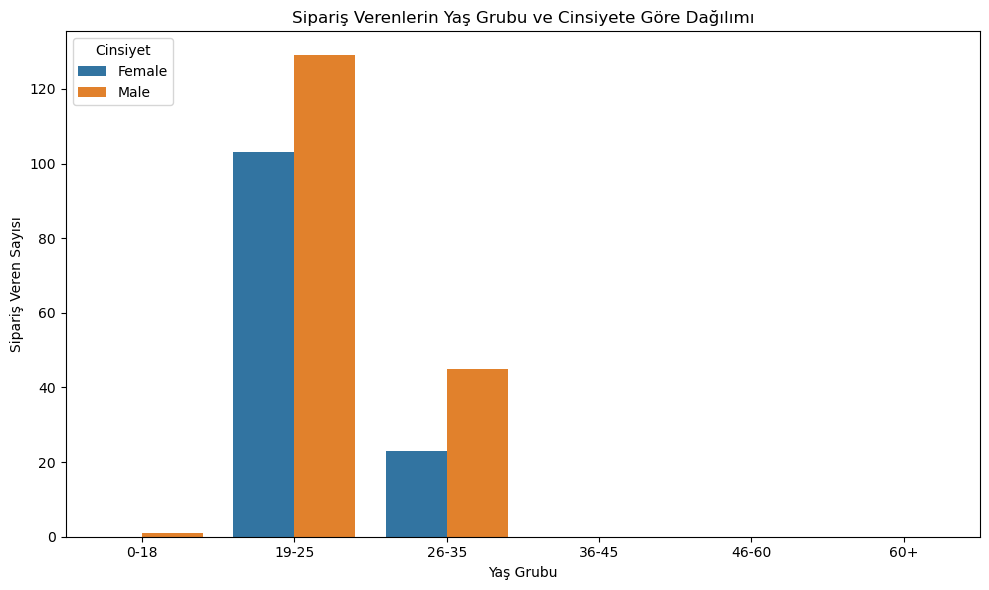

In [21]:
# Yaş Grubu ve Cinsiyete Göre Sipariş Veren Sayısı (Gruplu Bar Plot)

plt.figure(figsize=(10, 6))
sns.countplot(data=yes_df, x='AgeGroup', hue='Gender', order=['0-18', '19-25', '26-35', '36-45', '46-60', '60+'])
plt.title("Sipariş Verenlerin Yaş Grubu ve Cinsiyete Göre Dağılımı")
plt.xlabel("Yaş Grubu")
plt.ylabel("Sipariş Veren Sayısı")
plt.legend(title='Cinsiyet')
plt.tight_layout()
plt.show()


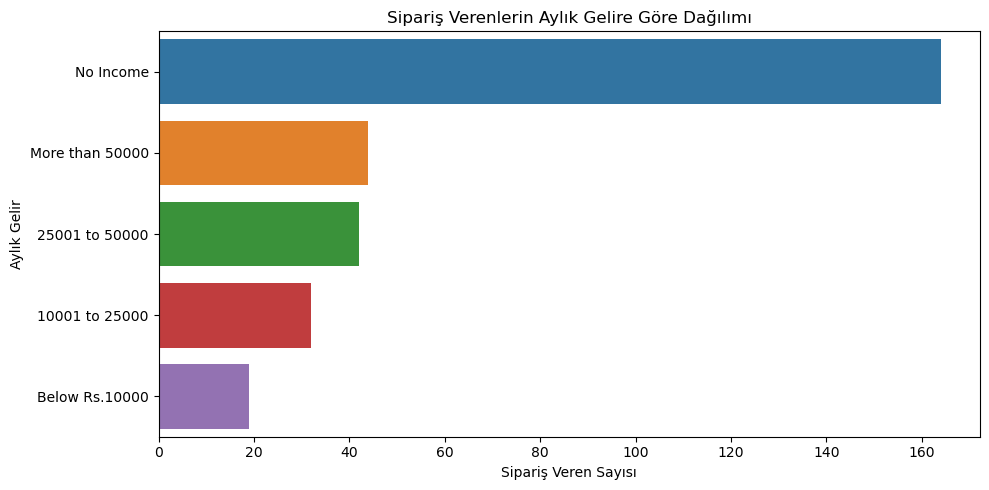

In [22]:
# Aylık Gelir – Sipariş İlişkisi

plt.figure(figsize=(10, 5))
sns.countplot(data=yes_df, y='Monthly Income', order=yes_df['Monthly Income'].value_counts().index)
plt.title("Sipariş Verenlerin Aylık Gelire Göre Dağılımı")
plt.xlabel("Sipariş Veren Sayısı")
plt.ylabel("Aylık Gelir")
plt.tight_layout()
plt.show()


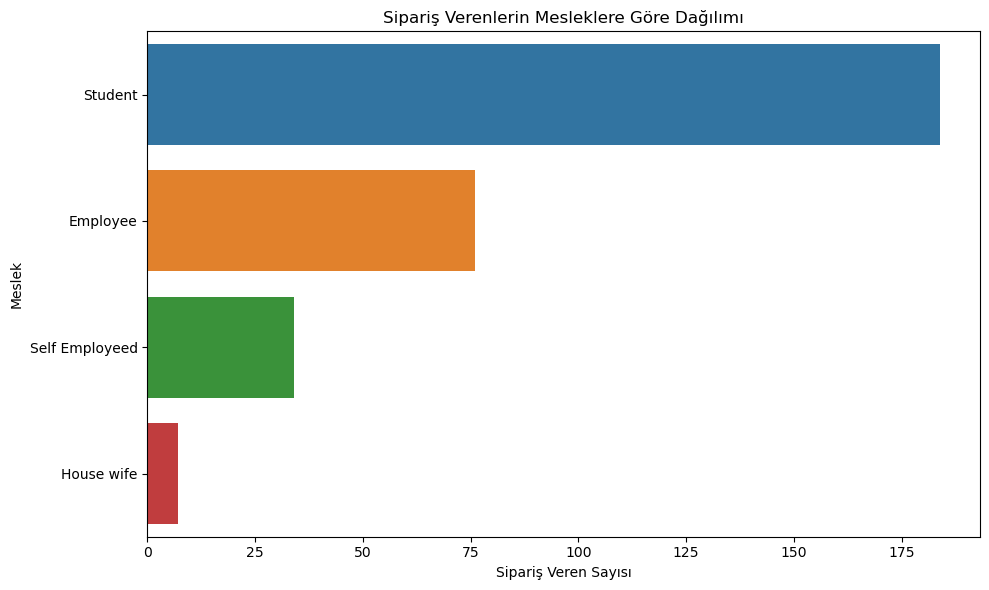

In [23]:
# Meslek – Sipariş İlişkisi

plt.figure(figsize=(10, 6))
sns.countplot(data=yes_df, y='Occupation', order=yes_df['Occupation'].value_counts().index)
plt.title("Sipariş Verenlerin Mesleklere Göre Dağılımı")
plt.xlabel("Sipariş Veren Sayısı")
plt.ylabel("Meslek")
plt.tight_layout()
plt.show()


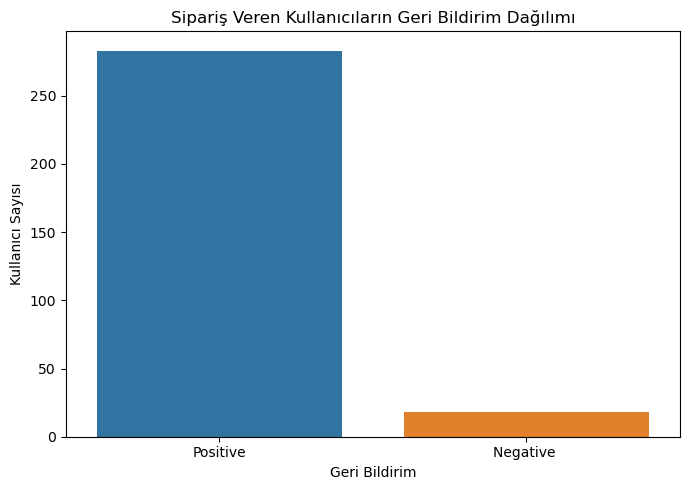

In [24]:
#Feedback – Sipariş İlişkisi

plt.figure(figsize=(7, 5))
sns.countplot(data=yes_df, x='Feedback', order=yes_df['Feedback'].value_counts().index)
plt.title("Sipariş Veren Kullanıcıların Geri Bildirim Dağılımı")
plt.xlabel("Geri Bildirim")
plt.ylabel("Kullanıcı Sayısı")
plt.tight_layout()
plt.show()


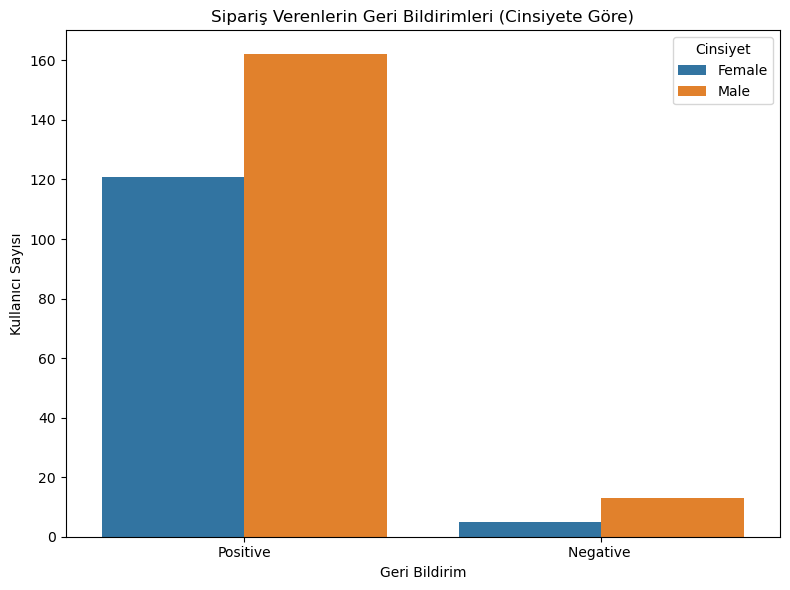

In [25]:
# Geri Bildirimleri Cinsiyete göre böldüğümüzde
plt.figure(figsize=(8, 6))
sns.countplot(data=yes_df, x='Feedback', hue='Gender', order=yes_df['Feedback'].value_counts().index)
plt.title("Sipariş Verenlerin Geri Bildirimleri (Cinsiyete Göre)")
plt.xlabel("Geri Bildirim")
plt.ylabel("Kullanıcı Sayısı")
plt.legend(title="Cinsiyet")
plt.tight_layout()
plt.show()


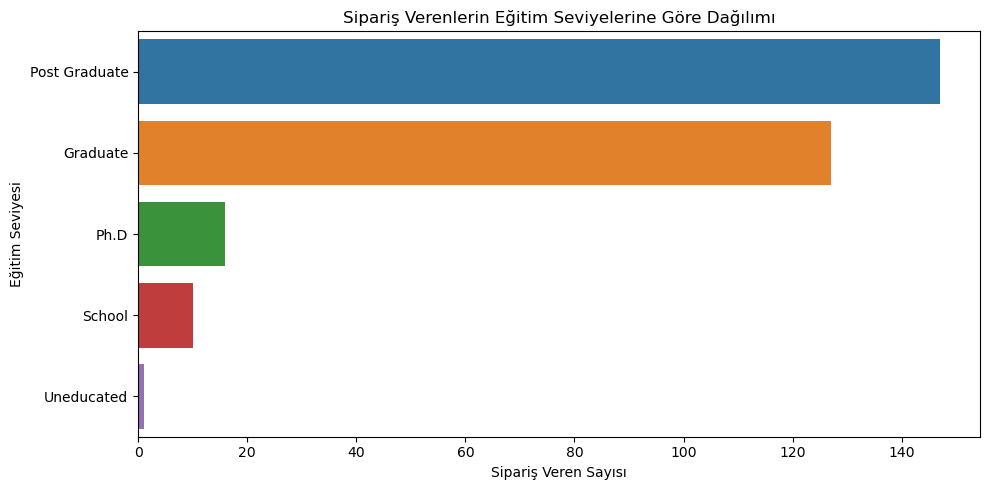

In [26]:
# Hangi eğitim seviyesine sahip kişiler daha çok sipariş veriyor?
# Eğitim seviyesiyle sipariş verme arasında bir örüntü var mı?


plt.figure(figsize=(10, 5))
sns.countplot(data=yes_df, y='Educational Qualifications', order=yes_df['Educational Qualifications'].value_counts().index)
plt.title("Sipariş Verenlerin Eğitim Seviyelerine Göre Dağılımı")
plt.xlabel("Sipariş Veren Sayısı")
plt.ylabel("Eğitim Seviyesi")
plt.tight_layout()
plt.show()



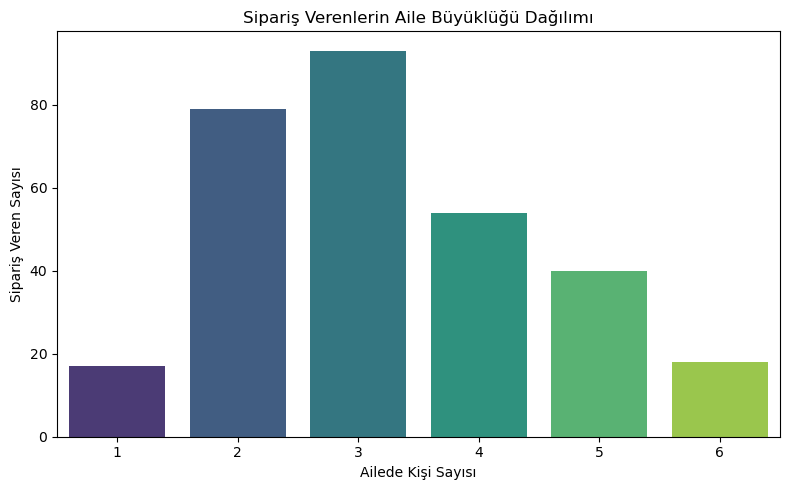

In [27]:
# Kalabalık aileler daha mı çok sipariş veriyor?

# Tek yaşayanlar sipariş verme davranışında farklılık gösteriyor mu?

plt.figure(figsize=(8, 5))
sns.countplot(data=yes_df, x='Family size', palette='viridis')
plt.title("Sipariş Verenlerin Aile Büyüklüğü Dağılımı")
plt.xlabel("Ailede Kişi Sayısı")
plt.ylabel("Sipariş Veren Sayısı")
plt.tight_layout()
plt.show()


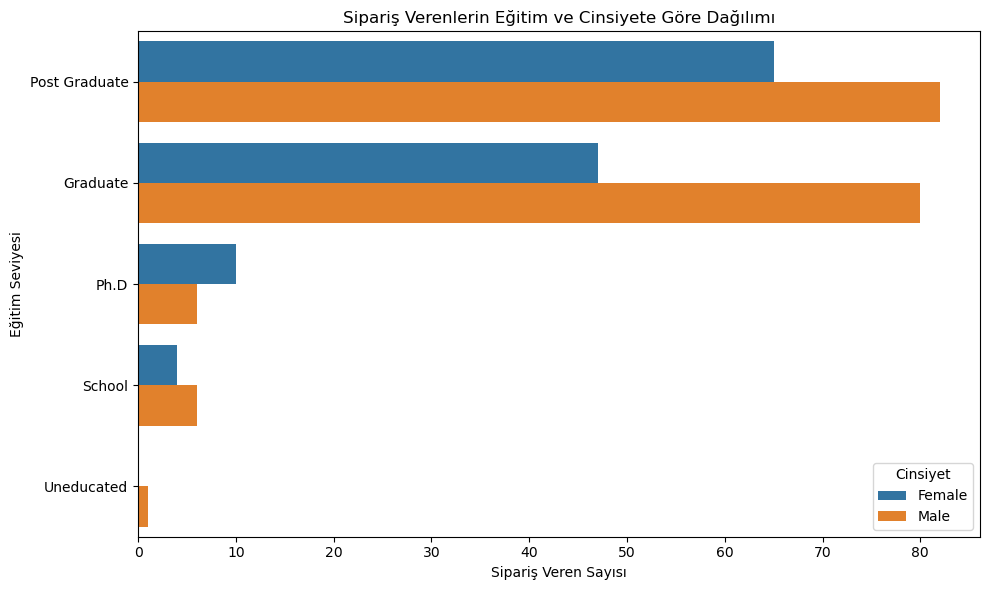

In [28]:
# "Hangi eğitim seviyesindeki kadınlar ve erkekler sipariş veriyor?"

plt.figure(figsize=(10, 6))
sns.countplot(data=yes_df, y='Educational Qualifications', hue='Gender',
              order=yes_df['Educational Qualifications'].value_counts().index)
plt.title("Sipariş Verenlerin Eğitim ve Cinsiyete Göre Dağılımı")
plt.xlabel("Sipariş Veren Sayısı")
plt.ylabel("Eğitim Seviyesi")
plt.legend(title='Cinsiyet')
plt.tight_layout()
plt.show()


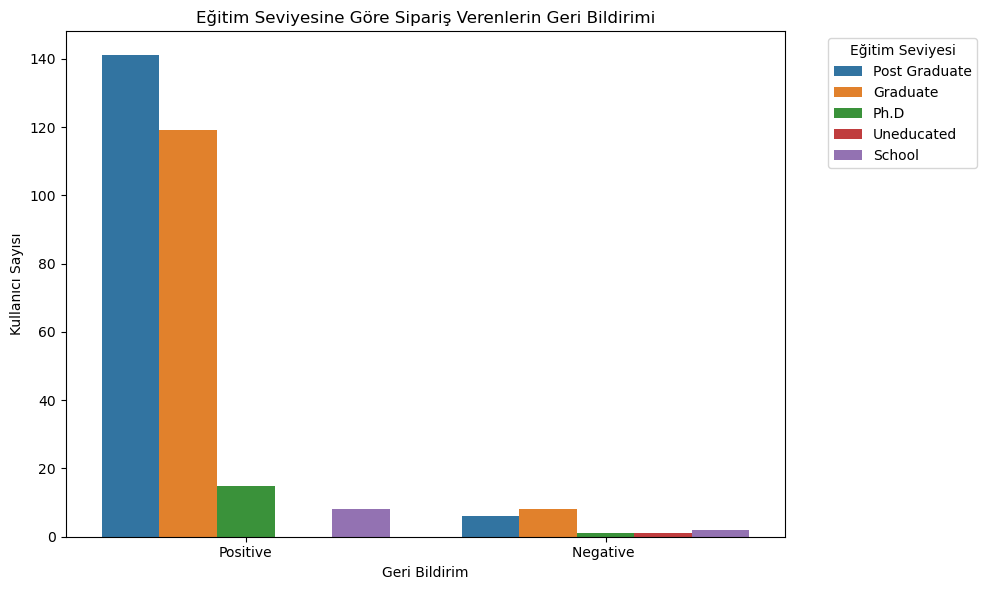

In [29]:
# "Eğitim seviyesine göre müşteri memnuniyeti nasıl değişiyor?"

plt.figure(figsize=(10, 6))
sns.countplot(data=yes_df, x='Feedback', hue='Educational Qualifications',
              order=yes_df['Feedback'].value_counts().index)
plt.title("Eğitim Seviyesine Göre Sipariş Verenlerin Geri Bildirimi")
plt.xlabel("Geri Bildirim")
plt.ylabel("Kullanıcı Sayısı")
plt.legend(title="Eğitim Seviyesi", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


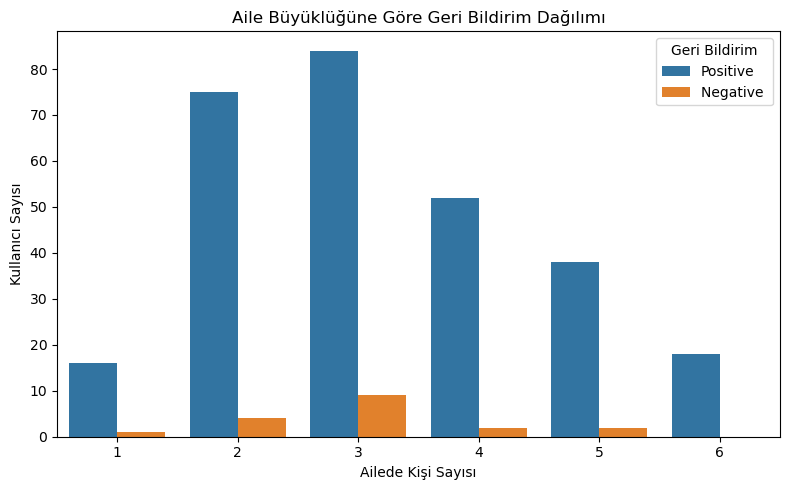

In [30]:
# "Ailedeki kişi sayısı arttıkça kullanıcıların geri bildirimi değişiyor mu?"

plt.figure(figsize=(8, 5))
sns.countplot(data=yes_df, x='Family size', hue='Feedback',
              order=sorted(yes_df['Family size'].unique()))
plt.title("Aile Büyüklüğüne Göre Geri Bildirim Dağılımı")
plt.xlabel("Ailede Kişi Sayısı")
plt.ylabel("Kullanıcı Sayısı")
plt.legend(title="Geri Bildirim")
plt.tight_layout()
plt.show()



In [31]:
# Gereksiz sütunları kaldırma
df_clean = df.drop(columns=['Unnamed: 12'])

In [32]:
# Eksik veri kontrolü
print(df_clean.isnull().sum())

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
AgeGroup                      0
dtype: int64


In [33]:
# Eksik verileri satır bazında düşürme (veya alternatif doldurma)
df_clean = df_clean.dropna()

In [34]:
# Cinsiyet sütunundaki yazım tutarsızlıklarını düzeltme
df_clean['Gender'] = df_clean['Gender'].str.strip().str.capitalize()

In [35]:
# Marital Status düzeltme (örneğin "single", "Single" gibi farklılıkları düzelt)
df_clean['Marital Status'] = df_clean['Marital Status'].str.strip().str.capitalize()

In [36]:
# Age sütunundaki mantıksız değerleri kontrol et
print(df_clean['Age'].describe())

count    388.000000
mean      24.628866
std        2.975593
min       18.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       33.000000
Name: Age, dtype: float64


In [37]:
bins = [17, 20, 23, 26, 30, 33]
labels = ['18-20', '21-23', '24-26', '27-30', '31-33']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)


In [38]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12,AgeGroup
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes,19-25
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes,19-25
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes,19-25
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes,19-25
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes,19-25


In [39]:
df_clean.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,AgeGroup
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,18-20
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,24-26
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,21-23
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,21-23
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,21-23


/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


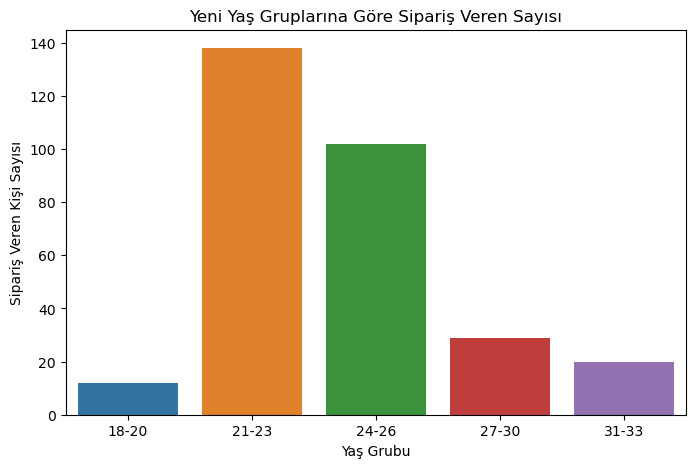

In [40]:
# Sadece sipariş verenler
yes_clean = df_clean[df_clean['Output'] == 'Yes']

plt.figure(figsize=(8,5))
sns.countplot(data=yes_clean, x='AgeGroup', order=labels)
plt.title("Yeni Yaş Gruplarına Göre Sipariş Veren Sayısı")
plt.xlabel("Yaş Grubu")
plt.ylabel("Sipariş Veren Kişi Sayısı")
plt.show()

/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Applications/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


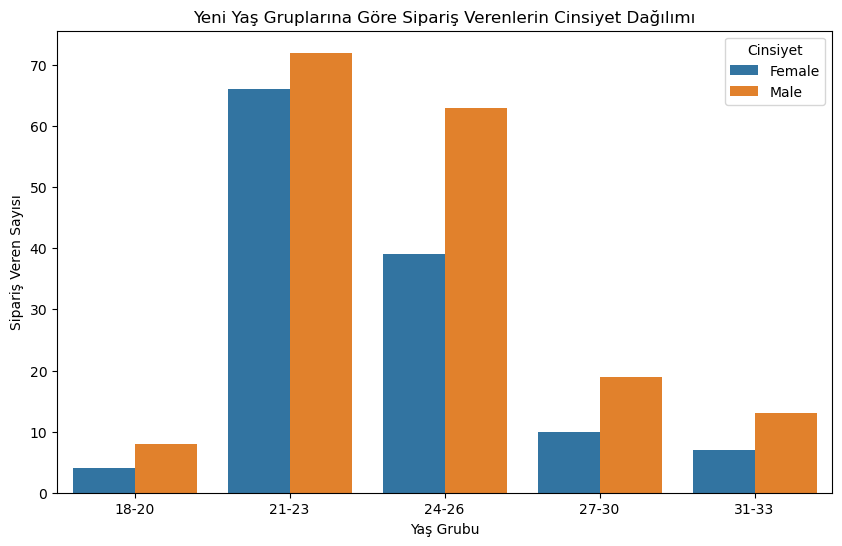

In [41]:
plt.figure(figsize=(10,6))
sns.countplot(data=yes_clean, x='AgeGroup', hue='Gender', order=labels)
plt.title("Yeni Yaş Gruplarına Göre Sipariş Verenlerin Cinsiyet Dağılımı")
plt.xlabel("Yaş Grubu")
plt.ylabel("Sipariş Veren Sayısı")
plt.legend(title="Cinsiyet")
plt.show()



Bekar ve sipariş veren kişi sayısı: 229
Bekar ve sipariş veren kişilerin cinsiyet dağılımı:
Gender
Male      131
Female     98
Name: count, dtype: int64


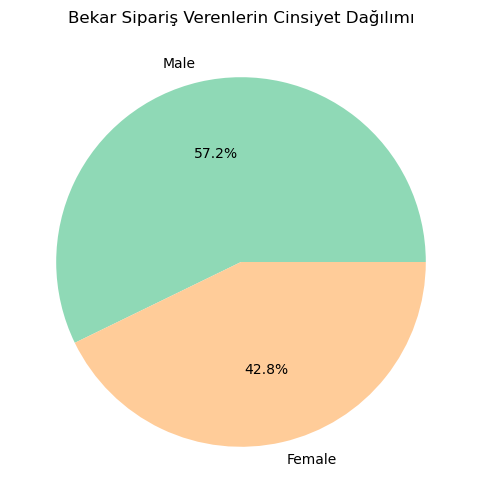

In [42]:
single_yes_clean = yes_clean[yes_clean['Marital Status'] == 'Single']

print(f"Bekar ve sipariş veren kişi sayısı: {single_yes_clean.shape[0]}")
print("Bekar ve sipariş veren kişilerin cinsiyet dağılımı:")
print(single_yes_clean['Gender'].value_counts())

# Grafik olarak
plt.figure(figsize=(6,6))
single_yes_clean['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#8fd9b6', '#ffcc99'])
plt.title("Bekar Sipariş Verenlerin Cinsiyet Dağılımı")
plt.ylabel('')
plt.show()


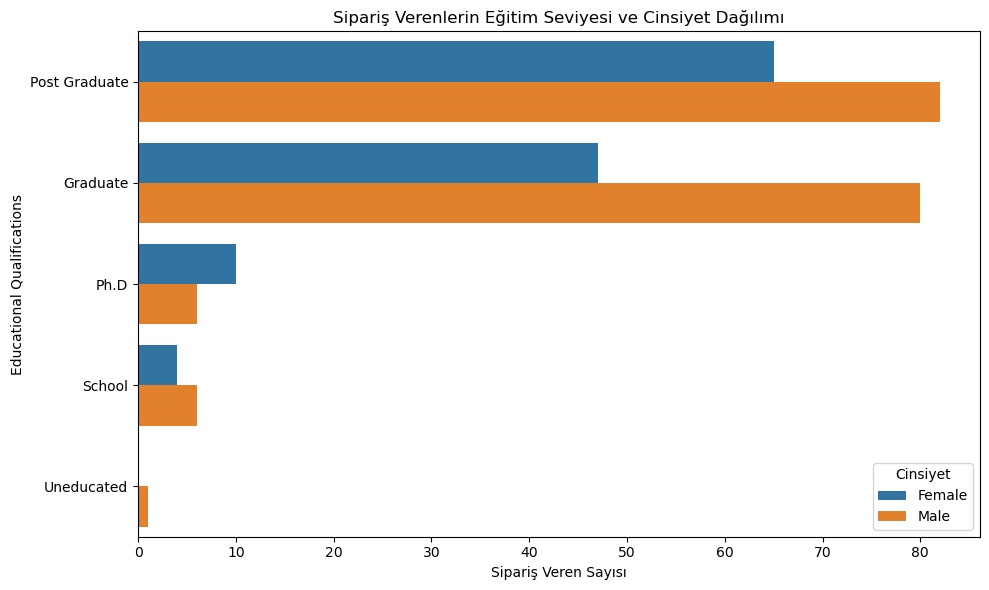

In [43]:
plt.figure(figsize=(10,6))
sns.countplot(data=yes_clean, y='Educational Qualifications', hue='Gender', order=yes_clean['Educational Qualifications'].value_counts().index)
plt.title("Sipariş Verenlerin Eğitim Seviyesi ve Cinsiyet Dağılımı")
plt.xlabel("Sipariş Veren Sayısı")
plt.legend(title='Cinsiyet')
plt.tight_layout()
plt.show()


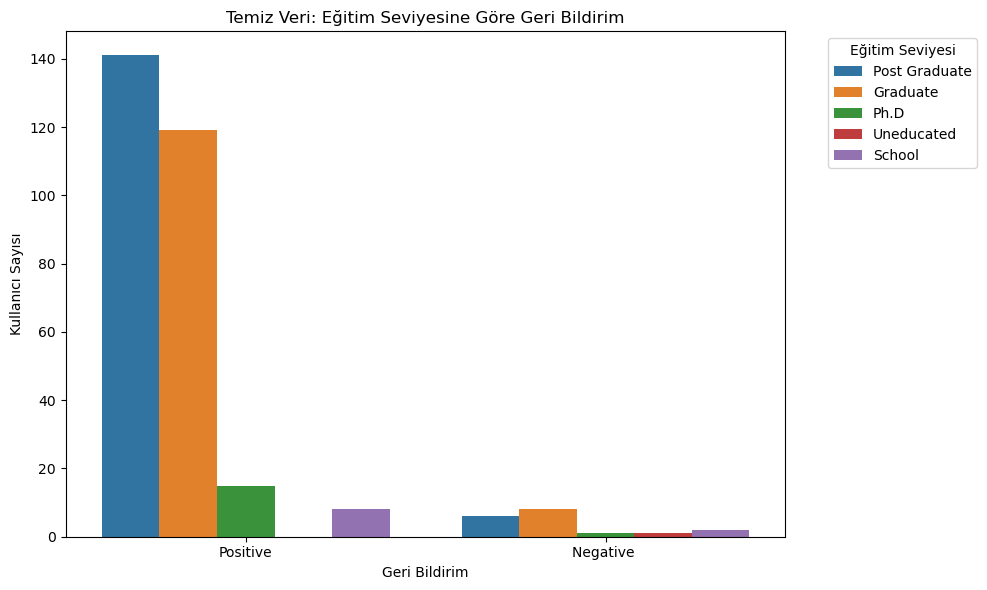

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(data=yes_clean, x='Feedback', hue='Educational Qualifications', order=yes_clean['Feedback'].value_counts().index)
plt.title("Temiz Veri: Eğitim Seviyesine Göre Geri Bildirim")
plt.xlabel("Geri Bildirim")
plt.ylabel("Kullanıcı Sayısı")
plt.legend(title='Eğitim Seviyesi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [45]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12', 'AgeGroup'],
      dtype='object')

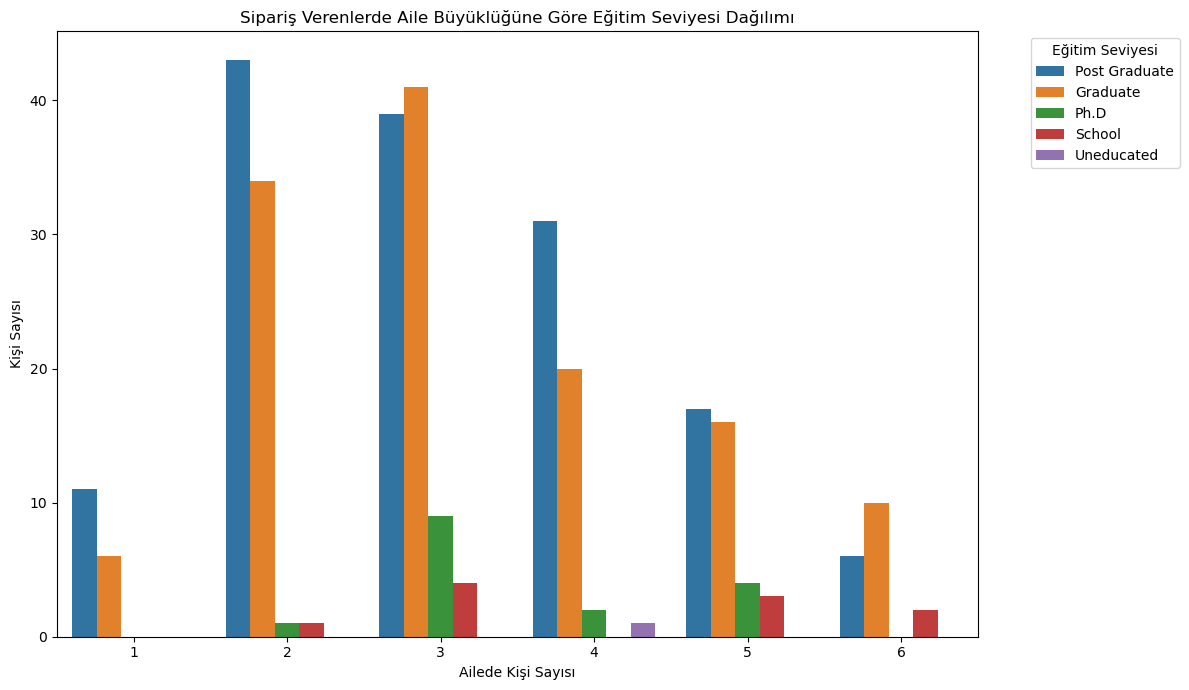

In [46]:
plt.figure(figsize=(12, 7))
sns.countplot(data=yes_clean, x='Family size', hue='Educational Qualifications',
              order=sorted(yes_clean['Family size'].unique()),
              hue_order=yes_clean['Educational Qualifications'].value_counts().index)
plt.title("Sipariş Verenlerde Aile Büyüklüğüne Göre Eğitim Seviyesi Dağılımı")
plt.xlabel("Ailede Kişi Sayısı")
plt.ylabel("Kişi Sayısı")
plt.legend(title="Eğitim Seviyesi", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()